# Chapter 06 Regression Splines: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-06-regression-splines-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Moving Beyond Linearity: Regression Splines".

Every function builds one self-contained, standalone Plotly HTML page and writes it
to ../_generated/. The matching chapter-splines-regression-splines.md file embeds each
page in an <iframe>.

Run directly to regenerate every figure:
    python chapter-splines-regression-splines-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline, LSQUnivariateSpline, UnivariateSpline

RNG = np.random.default_rng(7)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def saturation_curve(rho: np.ndarray, base_ms: float = 20.0) -> np.ndarray:
    """Mean latency under an M/M/1-style saturation curve as utilization rho -> 1."""
    return base_ms / (1.0 - rho)


In [4]:


def simulated_load_latency(n: int = 220, noise_scale: float = 3.0):
    rho = np.sort(RNG.uniform(0.05, 0.93, size=n))
    mean_latency = saturation_curve(rho)
    noise = RNG.normal(0, noise_scale, size=n) * (1 + mean_latency / 40)
    latency = np.clip(mean_latency + noise, 1, None)
    return rho, latency


In [5]:


# ---------------------------------------------------------------------------
# Figure 1: OLS line forced onto the saturation curve
# ---------------------------------------------------------------------------
def fig_linear_misfit() -> go.Figure:
    ranges = [(0.05, 0.93), (0.05, 0.75), (0.05, 0.5)]
    frames = []
    for lo, hi in ranges:
        rho, latency = simulated_load_latency(n=200)
        mask = (rho >= lo) & (rho <= hi)
        rho_r, lat_r = rho[mask], latency[mask]
        coef = np.polyfit(rho_r, lat_r, deg=1)
        grid = np.linspace(lo, hi, 100)
        fit = np.polyval(coef, grid)
        true_curve = saturation_curve(grid)
        frames.append(
            go.Frame(
                name=f"{lo:.2f}-{hi:.2f}",
                data=[
                    go.Scatter(x=rho_r, y=lat_r, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true saturation curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name="OLS line",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="An OLS line forced through a saturating load-latency curve",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Utilization range shown: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 2: polynomial degree and the Runge phenomenon
# ---------------------------------------------------------------------------
def fig_poly_degree() -> go.Figure:
    rho, latency = simulated_load_latency(n=180, noise_scale=2.5)
    grid = np.linspace(rho.min(), rho.max(), 300)
    true_curve = saturation_curve(grid)
    degrees = [2, 4, 6, 9, 12]
    frames = []
    for deg in degrees:
        coef = np.polyfit(rho, latency, deg=deg)
        fit = np.polyval(coef, grid)
        frames.append(
            go.Frame(
                name=str(deg),
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name=f"degree {deg} fit",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Polynomial regression degree vs. the Runge phenomenon",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 500],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Polynomial degree: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 3: regression spline as knot count grows
# ---------------------------------------------------------------------------
def fig_knot_count() -> go.Figure:
    rho, latency = simulated_load_latency(n=220, noise_scale=2.5)
    grid = np.linspace(rho.min() + 0.01, rho.max() - 0.01, 300)
    true_curve = saturation_curve(grid)
    knot_counts = [2, 4, 8, 12]
    frames = []
    for k in knot_counts:
        interior_knots = np.linspace(rho.min(), rho.max(), k + 2)[1:-1]
        spline = LSQUnivariateSpline(rho, latency, t=interior_knots, k=3)
        fit = spline(grid)
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name=f"{k}-knot cubic spline",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A cubic regression spline as the number of interior knots grows",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-20, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Interior knots: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 4: smoothing spline as the roughness penalty (lambda / s) changes
# ---------------------------------------------------------------------------
def fig_smoothing_lambda() -> go.Figure:
    rho, latency = simulated_load_latency(n=220, noise_scale=2.5)
    grid = np.linspace(rho.min(), rho.max(), 300)
    true_curve = saturation_curve(grid)
    n = len(rho)
    s_multipliers = [0.02, 0.2, 1.0, 5.0, 20.0]
    frames = []
    for mult in s_multipliers:
        s_value = mult * n
        spline = UnivariateSpline(rho, latency, s=s_value, k=3)
        fit = spline(grid)
        frames.append(
            go.Frame(
                name=f"{mult:.2f}",
                data=[
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.6)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=fit, mode="lines", name="smoothing spline",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Smoothing spline fit as the roughness penalty increases",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-20, 400],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Relative penalty strength: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 5: Gaussian process posterior mean and credible band
# ---------------------------------------------------------------------------
def squared_exponential_kernel(x1, x2, length_scale, variance=1.0):
    diff = x1[:, None] - x2[None, :]
    return variance * np.exp(-0.5 * (diff / length_scale) ** 2)


In [10]:


def gp_posterior(x_train, y_train, x_grid, length_scale, noise_var, variance=1.0):
    k_xx = squared_exponential_kernel(x_train, x_train, length_scale, variance)
    k_xx += noise_var * np.eye(len(x_train))
    k_xs = squared_exponential_kernel(x_train, x_grid, length_scale, variance)
    k_ss = squared_exponential_kernel(x_grid, x_grid, length_scale, variance)

    k_inv = np.linalg.inv(k_xx)
    mean = k_xs.T @ k_inv @ y_train
    cov = k_ss - k_xs.T @ k_inv @ k_xs
    std = np.sqrt(np.clip(np.diag(cov), 0, None))
    return mean, std


In [11]:


def fig_gp_posterior() -> go.Figure:
    rho, latency = simulated_load_latency(n=60, noise_scale=2.5)
    y_mean, y_std = latency.mean(), latency.std()
    y_norm = (latency - y_mean) / y_std
    grid = np.linspace(rho.min(), rho.max(), 150)
    true_curve = saturation_curve(grid)

    length_scales = [0.03, 0.08, 0.2, 0.5]
    frames = []
    for ls in length_scales:
        mean_norm, std_norm = gp_posterior(rho, y_norm, grid, length_scale=ls, noise_var=0.05)
        mean = mean_norm * y_std + y_mean
        std = std_norm * y_std
        upper = mean + 1.96 * std
        lower = mean - 1.96 * std
        frames.append(
            go.Frame(
                name=f"{ls:.2f}",
                data=[
                    go.Scatter(x=np.concatenate([grid, grid[::-1]]),
                               y=np.concatenate([upper, lower[::-1]]),
                               fill="toself", fillcolor="rgba(228,87,86,0.2)",
                               line=dict(color="rgba(255,255,255,0)"),
                               name="95% credible band", showlegend=True),
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#B7C7DB", size=6, opacity=0.7)),
                    go.Scatter(x=grid, y=true_curve, mode="lines", name="true curve",
                               line=dict(color="#54A24B", width=2, dash="dot")),
                    go.Scatter(x=grid, y=mean, mode="lines", name="GP posterior mean",
                               line=dict(color="#E45756", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Gaussian process posterior mean and credible band at varying length-scales",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 450],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Kernel length-scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [12]:


# ---------------------------------------------------------------------------
# Figure 6: individual basis functions, by family (polynomial, step, spline)
# ---------------------------------------------------------------------------
def fig_basis_functions() -> go.Figure:
    grid = np.linspace(0, 1, 300)
    families = ["Polynomial (degree 0-3)", "Step functions (4 regions)",
                "Cubic spline (3 interior knots)"]
    frames = []

    # Polynomial basis: 1, x, x^2, x^3
    poly_curves = [grid ** k for k in range(4)]
    poly_names = ["b0(x) = 1", "b1(x) = x", "b2(x) = x^2", "b3(x) = x^3"]

    # Step-function basis: four indicator regions
    cuts = [0.0, 0.25, 0.5, 0.75, 1.0]
    step_curves = []
    step_names = []
    for i in range(4):
        curve = ((grid >= cuts[i]) & (grid < cuts[i + 1] if i < 3 else grid <= cuts[i + 1])).astype(float)
        step_curves.append(curve)
        step_names.append(f"indicator[{cuts[i]:.2f} <= x < {cuts[i+1]:.2f}]")

    # Cubic spline basis via B-splines with 3 interior knots
    from scipy.interpolate import BSpline
    interior_knots = [0.25, 0.5, 0.75]
    degree = 3
    knots = np.concatenate([[0] * (degree + 1), interior_knots, [1] * (degree + 1)])
    n_basis = len(knots) - degree - 1
    spline_curves = []
    spline_names = []
    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1.0
        b = BSpline(knots, coeffs, degree, extrapolate=False)
        curve = np.nan_to_num(b(grid))
        spline_curves.append(curve)
        spline_names.append(f"B-spline basis {i + 1}")

    colors = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#B279A2", "#72B7B2", "#FF9DA6"]

    for name, curves, curve_names in [
        (families[0], poly_curves, poly_names),
        (families[1], step_curves, step_names),
        (families[2], spline_curves, spline_names),
    ]:
        traces = [
            go.Scatter(x=grid, y=curve, mode="lines", name=cname,
                       line=dict(color=colors[i % len(colors)], width=3))
            for i, (curve, cname) in enumerate(zip(curves, curve_names))
        ]
        frames.append(go.Frame(name=name, data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Every fix in this chapter is a linear model on a different set of basis "
              "functions",
        xaxis_title="x (normalized utilization)",
        yaxis_title="b_k(x)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Basis function family: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [13]:


FIGURES = {
    "chapter-splines-fig-linear-misfit": fig_linear_misfit,
    "chapter-splines-fig-poly-degree": fig_poly_degree,
    "chapter-splines-fig-basis-functions": fig_basis_functions,
    "chapter-splines-fig-knot-count": fig_knot_count,
    "chapter-splines-fig-smoothing-lambda": fig_smoothing_lambda,
    "chapter-splines-fig-gp-posterior": fig_gp_posterior,
}


**`chapter-splines-fig-linear-misfit`**

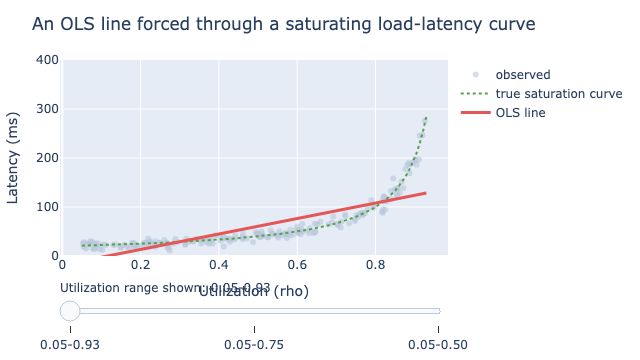

In [14]:
fig = FIGURES["chapter-splines-fig-linear-misfit"]()
fig

**`chapter-splines-fig-poly-degree`**

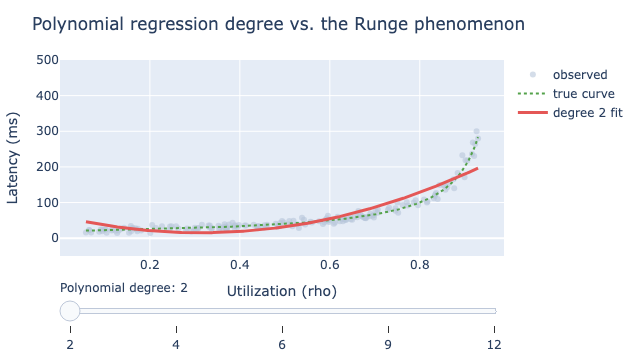

In [15]:
fig = FIGURES["chapter-splines-fig-poly-degree"]()
fig

**`chapter-splines-fig-basis-functions`**

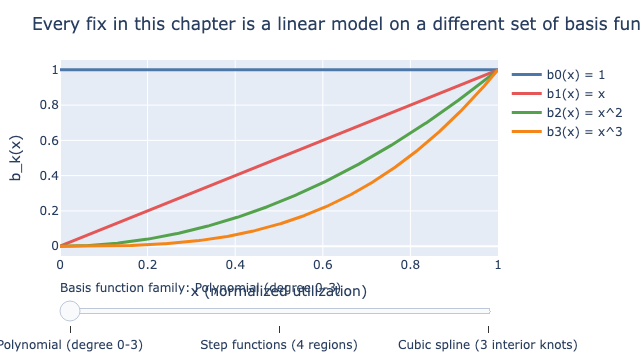

In [16]:
fig = FIGURES["chapter-splines-fig-basis-functions"]()
fig

**`chapter-splines-fig-knot-count`**

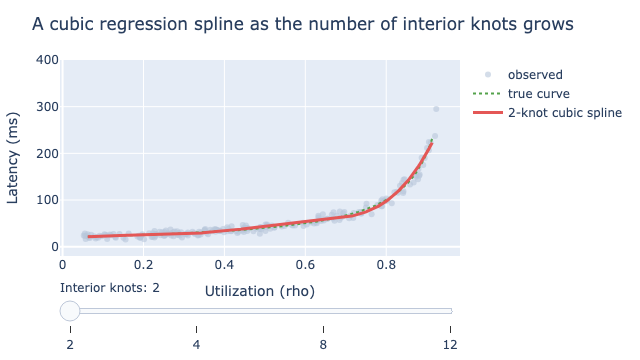

In [17]:
fig = FIGURES["chapter-splines-fig-knot-count"]()
fig

**`chapter-splines-fig-smoothing-lambda`**

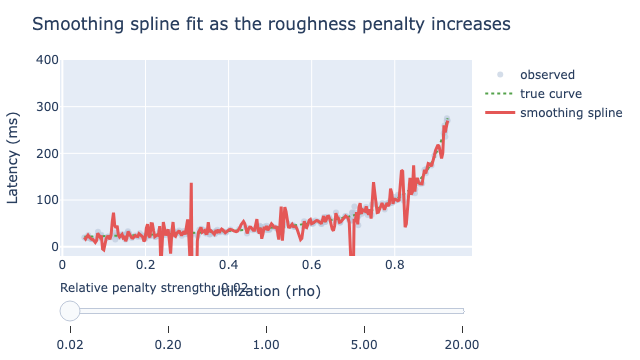

In [18]:
fig = FIGURES["chapter-splines-fig-smoothing-lambda"]()
fig

**`chapter-splines-fig-gp-posterior`**

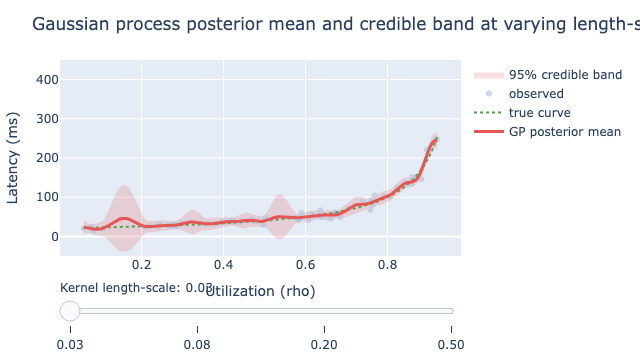

In [19]:
fig = FIGURES["chapter-splines-fig-gp-posterior"]()
fig